# Trend detection — regime timeline

- **1m bars** define the state (fast vs slow EMA); ticks only forward-fill that state — for analysis, use **bar-level** series from `bars_with_trend()`.
- **`state_transition_table()`** lists every **change** (down / up / range), with **run length** in bars after each change.
- **`plot_regime_timeline()`** draws: price + EMAs with shaded regime, state step plot, transition markers.

In [6]:
import os

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from poc_trend_detection import (
    bars_with_trend,
    plot_regime_timeline,
    state_transition_table,
    verify_bars_state_matches_rule,
)

data_folder = "data"
symbol = "BTCUSDT"
year = 2025
month = 1
path = os.path.join(data_folder, f"{symbol}-aggTrades-{year}-{month:02d}.parquet")

In [7]:
if not os.path.isfile(path):
    raise FileNotFoundError(f"Missing file: {path}")

df = pl.read_parquet(path)
eps_pct = 0.0003
bars = bars_with_trend(df, fast=20, slow=50, eps_pct=eps_pct)
n_bad, bad_idx = verify_bars_state_matches_rule(bars, eps_pct=eps_pct)
if n_bad:
    raise AssertionError(
        f"state vs EMA rule: {n_bad} mismatches; first indices: {bad_idx[:15]}"
    )
print("OK: state matches (ema_fast - ema_slow) / |ema_slow| vs eps_pct on every bar.\n")

trans = state_transition_table(bars)

print(f"1m bars: {bars.height:,}  |  ticks in file: {df.height:,}")
print("\nState share (all 1m bars):")
st = bars["state"].to_numpy()
for u in (-1, 0, 1):
    p = 100.0 * np.mean(st == u)
    print(f"  {u:2d}: {p:5.2f}%")

print("\nTransitions (first 25):")
display(trans.head(25))
print(f"\nTotal transitions (including t0): {len(trans)}")

OK: state matches (ema_fast - ema_slow) / |ema_slow| vs eps_pct on every bar.

1m bars: 44,640  |  ticks in file: 55,419,154

State share (all 1m bars):
  -1: 33.24%
   0: 31.01%
   1: 35.75%

Transitions (first 25):


,bar_index,time,from_state,to_state,duration_bars
0,0,2025-01-01 00:00:00,NaN,0,19
1,19,2025-01-01 00:19:00,0.0,1,64
2,83,2025-01-01 01:23:00,1.0,0,26
3,109,2025-01-01 01:49:00,0.0,-1,42
4,151,2025-01-01 02:31:00,-1.0,0,13
5,164,2025-01-01 02:44:00,0.0,1,33
6,197,2025-01-01 03:17:00,1.0,0,18
7,215,2025-01-01 03:35:00,0.0,-1,6
8,221,2025-01-01 03:41:00,-1.0,0,7
9,228,2025-01-01 03:48:00,0.0,-1,8



Total transitions (including t0): 1735


### Pair counts: where the regime *moved*
Use `from_state → to_state` to see flips into **up (1)**, **range (0)**, or **down (-1)**.

In [8]:
edges = trans.dropna(subset=["from_state"]).copy()
edges["pair"] = edges["from_state"].astype(int).astype(str) + " → " + edges["to_state"].astype(int).astype(str)
pair_counts = edges["pair"].value_counts().sort_index()
display(pair_counts.to_frame("count"))

run_len = trans["duration_bars"].dropna()
print("Run length (bars) after each transition — summary:")
print(run_len.describe())

,count
pair,
-1 → 0,429
-1 → 1,3
0 → -1,432
0 → 1,434
1 → 0,436


Run length (bars) after each transition — summary:
count    1735.000000
mean       25.729107
std        29.270353
min         1.000000
25%         7.000000
50%        16.000000
75%        34.000000
max       257.000000
Name: duration_bars, dtype: float64


### Full month chart (can be dense)
Use **`zoom_last_bars`** in the next cell for a readable window.

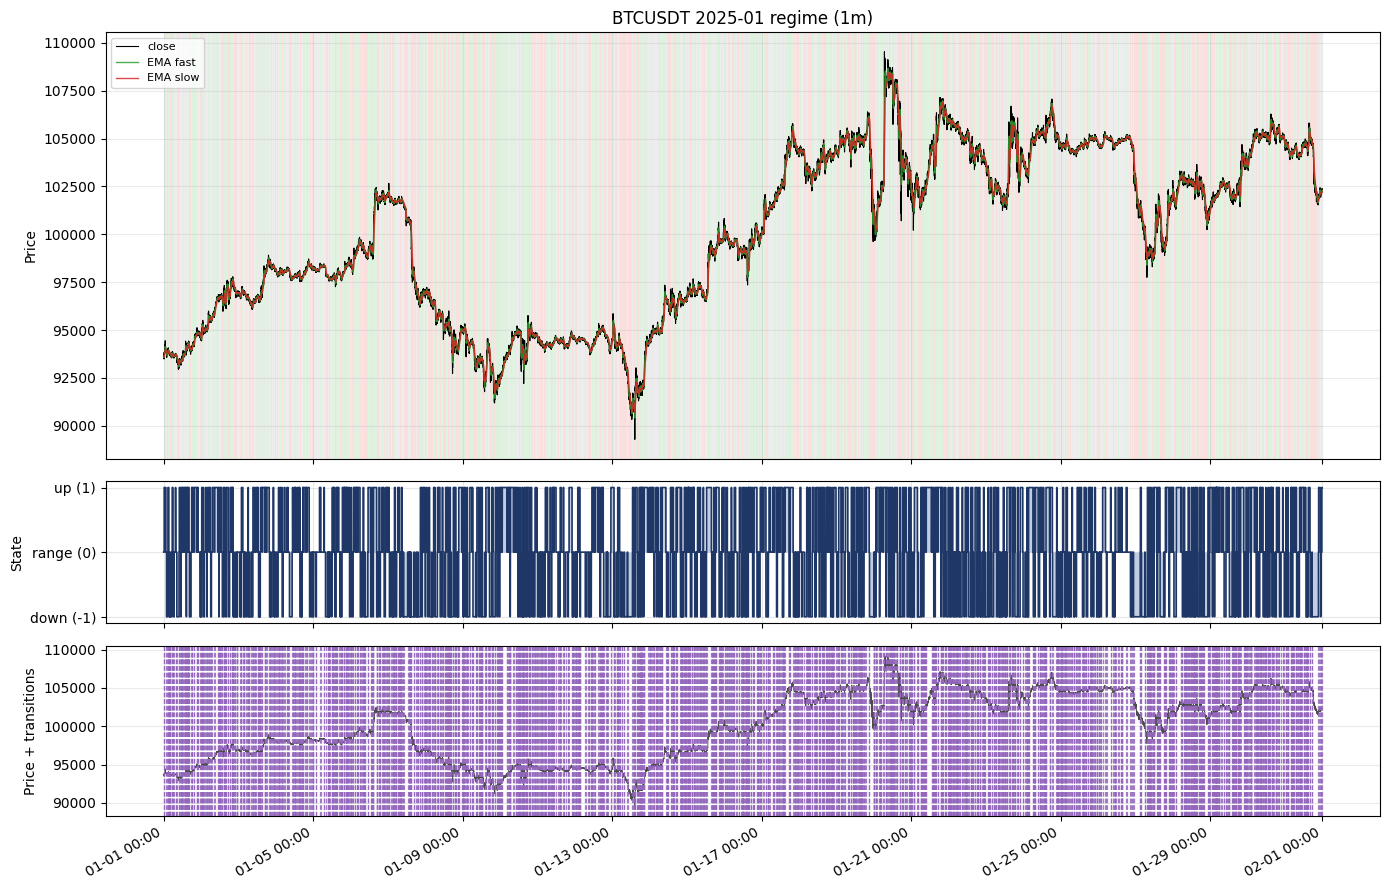

In [9]:
fig, _ = plot_regime_timeline(
    bars,
    trans,
    title=f"{symbol} {year}-{month:02d} regime (1m)",
    zoom_last_bars=None,
    figsize=(14, 9),
)
plt.show()

### Zoom: last *N* bars (when the month is long)
Purple dashed lines = regime change (same index rules as the transition table).

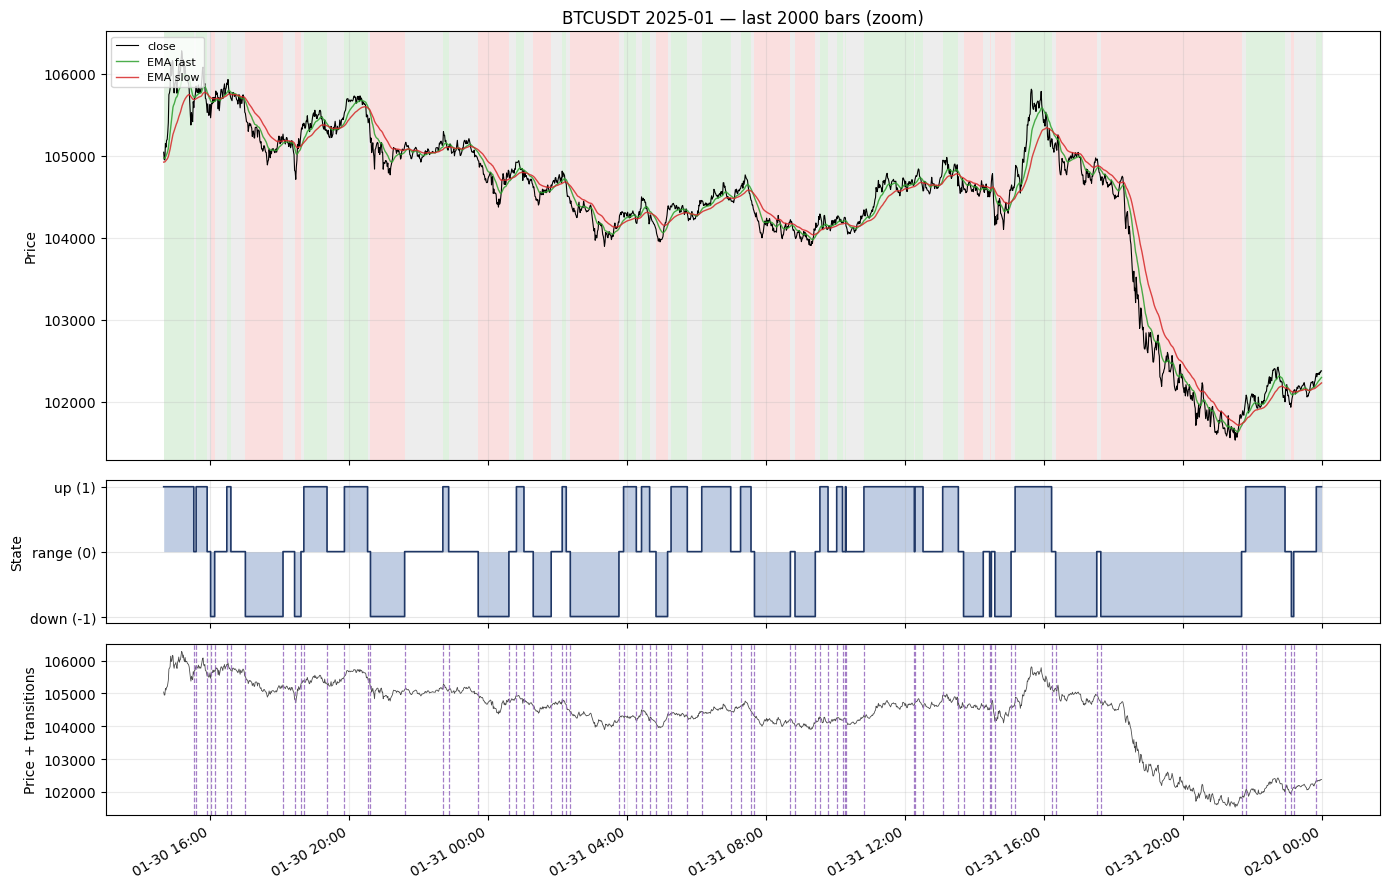

In [10]:
ZOOM = 2000  # ~1.4 days of 1m bars; increase/decrease as you like

fig, _ = plot_regime_timeline(
    bars,
    trans,
    title=f"{symbol} {year}-{month:02d} — last {ZOOM} bars",
    zoom_last_bars=ZOOM,
    figsize=(14, 9),
)
plt.show()